In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df=pd.read_csv("gene_expression_data.csv")
a=df.head()

df.shape
print(a)



        TP53      BRCA1       EGFR        MYC       KRAS       PTEN       RB1  \
0  11.222595  12.723709  10.143277  11.211367  12.305195  10.906039  8.234062   
1  12.917514  12.348381  13.548698  11.760092  12.756070   7.881631  5.840211   
2  12.542093  10.665728  14.161910  12.036765  11.587422   7.527628  9.369128   
3   4.280156   5.781823   4.665499   5.232050   5.669673   5.804657  6.590915   
4   3.521478   5.259883   3.799704   4.528962   3.695530   3.292533  6.631385   

        APC      VEGFA       HER2  ...      MDM2      BRAF    PIK3CA  \
0  8.415879  13.566241  11.928433  ...  5.144249  8.935053  6.591428   
1  9.080463  13.783525  14.165647  ...  5.515365  8.061085  8.638733   
2  8.561628  11.734579  12.192157  ...  8.638393  9.136965  7.240581   
3  5.911384   5.492451   3.929915  ...  7.023369  5.164090  4.772653   
4  7.776489   5.166452   6.846637  ...  6.740392  6.026084  8.424331   

         ATM    NOTCH1     FOXP3       IL6       TNF     GAPDH  diagnosis  
0   

In [ ]:
X=df.drop('diagnosis', axis=1)
Y=df['diagnosis']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y, test_size=0.2)
modle= RandomForestClassifier(random_state=42)

modle.fit(X_train,Y_train)

pred= modle.predict(X_test)

acc=accuracy_score(Y_test,pred)

print(f"accuracy= {acc*100:.3f}%")


accuracy= 100.000%


In [13]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modle, X, Y, cv=5)
print(scores)
print(f"Average: {scores.mean() * 100:.2f}%")


[1. 1. 1. 1. 1.]
Average: 100.00%


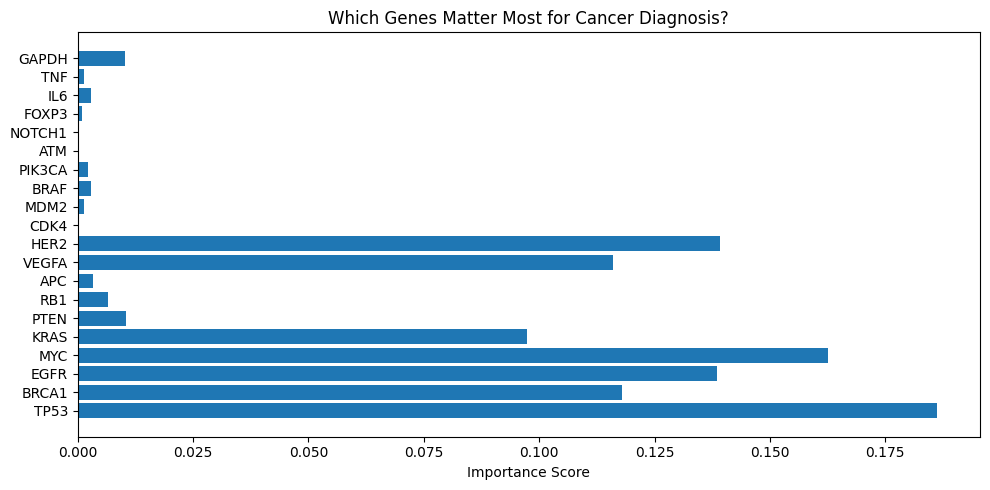

In [14]:
import matplotlib.pyplot as plt

importances = modle.feature_importances_

# Create a bar chart
plt.figure(figsize=(10, 5))
plt.barh(df.drop('diagnosis', axis=1).columns, importances)
plt.xlabel("Importance Score")
plt.title("Which Genes Matter Most for Cancer Diagnosis?")
plt.tight_layout()
plt.show()
